In [ ]:
import os
import sys
import time
import json
import shutil
import warnings
import subprocess
import importlib
import traceback

warnings.filterwarnings("ignore")

QUICK = False
SEED = 42
SCALE = 0.25 if QUICK else 1.0

N_MAIN = int(200_000 * SCALE)
D_MAIN = 64
N_RF = int(50_000 * SCALE)
D_RF = 32
N_NN_INDEX = int(50_000 * SCALE)
N_NN_QUERY = int(5_000 * SCALE)
N_DBSCAN = int(20_000 * SCALE)
N_MANIFOLD = int(60_000 * SCALE)
N_ACCEL = int(80_000 * SCALE)

RESULTS = []
NOTES = []


def banner(title):
    line = "=" * 78
    print(f"\n{line}\n  {title}\n{line}", flush=True)


def section(title, fn, *args, **kwargs):
    banner(title)
    t0 = time.perf_counter()
    try:
        fn(*args, **kwargs)
    except Exception:
        print(f"[!] Section skipped due to an error:\n{traceback.format_exc()}")
    print(f"[section wall time: {time.perf_counter() - t0:.1f}s]", flush=True)


def bootstrap():
    if shutil.which("nvidia-smi") is None:
        raise SystemExit(
            "No NVIDIA GPU found. In Colab: Runtime > Change runtime type > GPU."
        )
    print(subprocess.run(
        ["nvidia-smi",
         "--query-gpu=name,memory.total,compute_cap,driver_version",
         "--format=csv"],
        capture_output=True, text=True).stdout)

    try:
        import cuml
        print("cuML already available — skipping install.")
    except ImportError:
        print("Installing RAPIDS cuML (this takes ~1-3 minutes)...")
        pin = ""
        try:
            import cudf
            major_minor = ".".join(cudf.__version__.split("+")[0].split(".")[:2])
            pin = f"=={major_minor}.*"
            print(f"  Pinning to the preinstalled cuDF line: cuml-cu12{pin}")
        except Exception:
            print("  cuDF not found; installing the latest stable cuml-cu12.")
        cmd = [sys.executable, "-m", "pip", "install", "-q",
               "--extra-index-url=https://pypi.nvidia.com", f"cuml-cu12{pin}"]
        print("$ " + " ".join(cmd))
        rc = subprocess.run(cmd).returncode
        if rc != 0:
            raise SystemExit(
                "pip install failed. Alternative that always works on Colab:\n"
                "  !git clone https://github.com/rapidsai/rapidsai-csp-utils.git\n"
                "  !python rapidsai-csp-utils/colab/pip-install.py"
            )
        importlib.invalidate_caches()

    import cuml
    import cupy
    print(f"cuml   {cuml.__version__}")
    print(f"cupy   {cupy.__version__}")
    try:
        import cudf
        print(f"cudf   {cudf.__version__}")
    except Exception:
        pass
    import sklearn
    print(f"sklearn {sklearn.__version__}   (cuML requires scikit-learn >= 1.6)")


bootstrap()

import numpy as np
import cupy as cp
import cuml
import matplotlib.pyplot as plt

from cuml.datasets import make_classification as gpu_make_classification
from cuml.datasets import make_blobs as gpu_make_blobs

rng = np.random.RandomState(SEED)
cp.random.seed(SEED)


class Timer:
    def __init__(self, label, sync=True):
        self.label = label
        self.sync = sync

    def __enter__(self):
        if self.sync:
            cp.cuda.runtime.deviceSynchronize()
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, *exc):
        if self.sync:
            cp.cuda.runtime.deviceSynchronize()
        self.dt = time.perf_counter() - self.t0
        print(f"    {self.label:<44s} {self.dt:8.3f}s")
        return False


def to_numpy(a):
    if isinstance(a, cp.ndarray):
        return cp.asnumpy(a)
    if hasattr(a, "to_numpy"):
        return a.to_numpy()
    return np.asarray(a)


def record(task, cpu_s, gpu_s):
    RESULTS.append((task, cpu_s, gpu_s))
    if cpu_s and gpu_s:
        print(f"    -> {task}: {cpu_s / gpu_s:.1f}x speedup\n")


ACCEL_SCRIPT = f'''
import time
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import Ridge

X, y = make_blobs(n_samples={N_ACCEL}, n_features=32, centers=12, random_state=0)
X = X.astype("float32"); y = y.astype("float32")

t0 = time.perf_counter()
PCA(n_components=8).fit_transform(X)
KMeans(n_clusters=12, n_init=1, random_state=0).fit(X)
NearestNeighbors(n_neighbors=8).fit(X[:{N_ACCEL // 2}]).kneighbors(X[:5000])
Ridge(alpha=1.0).fit(X, y)

Ridge(alpha=1.0, positive=True).fit(X[:5000], y[:5000])

print("MODELTIME %.3f" % (time.perf_counter() - t0))
'''


def demo_accel():
    path = "/content/_accel_demo.py" if os.path.isdir("/content") else "_accel_demo.py"
    with open(path, "w") as f:
        f.write(ACCEL_SCRIPT)

    def run(cmd, label):
        print(f"\n$ {' '.join(cmd[1:])}")
        t0 = time.perf_counter()
        p = subprocess.run(cmd, capture_output=True, text=True)
        wall = time.perf_counter() - t0
        out = p.stdout + p.stderr
        model_s = None
        for line in out.splitlines():
            if line.startswith("MODELTIME"):
                model_s = float(line.split()[1])
        print(out.strip()[:4000])
        print(f"[{label}] model time = {model_s}s | process wall = {wall:.1f}s")
        return model_s

    cpu_s = run([sys.executable, path], "stock sklearn")

    cmd = [sys.executable, "-m", "cuml.accel", "--profile", path]
    gpu_s = run(cmd, "cuml.accel")
    if gpu_s is None:
        gpu_s = run([sys.executable, "-m", "cuml.accel", path], "cuml.accel")

    record("cuml.accel (sklearn script, unmodified)", cpu_s, gpu_s)
    NOTES.append(
        "cuml.accel needed ZERO source changes; the profile table above shows "
        "which calls ran on GPU and why Ridge(positive=True) fell back to CPU."
    )

In [ ]:
def demo_native_api():
    from cuml.preprocessing import StandardScaler
    from cuml.model_selection import train_test_split

    X, y = gpu_make_blobs(n_samples=50_000, n_features=8, centers=5,
                          random_state=SEED, dtype=np.float32)
    print(f"cuml.datasets output lives on device: {type(X).__module__}, "
          f"shape={X.shape}, dtype={X.dtype}")

    try:
        import cudf
        df = cudf.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])
        back = df.values
        ptr_a = X.__cuda_array_interface__["data"][0]
        ptr_b = back.__cuda_array_interface__["data"][0]
        print(f"CuPy ptr  = {hex(ptr_a)}")
        print(f"cuDF->CuPy= {hex(ptr_b)}")
        print("Same device pointer (true zero-copy)? ", ptr_a == ptr_b)
        print("Note: a column-major DataFrame round trip may re-pack; what "
              "matters is that no host (CPU) round trip ever happens.")

        scaled = StandardScaler().fit_transform(df)
        print(f"StandardScaler(cuDF) -> {type(scaled).__name__}")
    except Exception as e:
        print(f"cuDF interop skipped: {e}")

    from cuml.decomposition import PCA
    pca = PCA(n_components=3).fit(X)
    print(f"default (mirrors input)      -> {type(pca.transform(X)).__name__}")
    with cuml.using_output_type("numpy"):
        print(f"inside using_output_type()   -> {type(pca.transform(X)).__name__}")
    print(f"after the context manager    -> {type(pca.transform(X)).__name__}")
    NOTES.append(
        "Keep output_type as CuPy/cuDF inside a pipeline; converting to NumPy "
        "on every step forces a device->host copy and eats the speedup."
    )

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED)
    print(f"train_test_split -> {Xtr.shape} / {Xte.shape}, still on device: "
          f"{isinstance(Xtr, cp.ndarray)}")

In [ ]:
def demo_benchmarks():
    from sklearn.decomposition import PCA as skPCA
    from sklearn.cluster import KMeans as skKMeans, DBSCAN as skDBSCAN
    from sklearn.neighbors import NearestNeighbors as skNN
    from sklearn.linear_model import LogisticRegression as skLR
    from sklearn.ensemble import RandomForestClassifier as skRF

    from cuml.decomposition import PCA as cuPCA
    from cuml.cluster import KMeans as cuKMeans, DBSCAN as cuDBSCAN
    from cuml.neighbors import NearestNeighbors as cuNN
    from cuml.linear_model import LogisticRegression as cuLR
    from cuml.ensemble import RandomForestClassifier as cuRF

    print(f"Generating {N_MAIN:,} x {D_MAIN} on the GPU...")
    Xg, yg = gpu_make_classification(n_samples=N_MAIN, n_features=D_MAIN,
                                     n_informative=32, n_classes=4,
                                     random_state=SEED)
    Xg = Xg.astype(cp.float32)
    yg = yg.astype(cp.int32)
    Xc, yc = cp.asnumpy(Xg), cp.asnumpy(yg)
    print(f"  device array: {Xg.nbytes / 1e6:.0f} MB\n")

    print("PCA (n_components=16)")
    with Timer("sklearn", sync=False) as t:
        skPCA(n_components=16, random_state=SEED).fit_transform(Xc)
    cpu = t.dt
    with Timer("cuML") as t:
        cuPCA(n_components=16, random_state=SEED).fit_transform(Xg)
    record("PCA", cpu, t.dt)

    print("KMeans (k=16)")
    with Timer("sklearn", sync=False) as t:
        skKMeans(n_clusters=16, n_init=1, max_iter=100,
                 random_state=SEED).fit(Xc)
    cpu = t.dt
    with Timer("cuML") as t:
        cuKMeans(n_clusters=16, n_init=1, max_iter=100,
                 random_state=SEED).fit(Xg)
    record("KMeans", cpu, t.dt)

    print(f"NearestNeighbors k=16 ({N_NN_INDEX:,} index / {N_NN_QUERY:,} query)")
    idx_g, q_g = Xg[:N_NN_INDEX], Xg[N_NN_INDEX:N_NN_INDEX + N_NN_QUERY]
    idx_c, q_c = cp.asnumpy(idx_g), cp.asnumpy(q_g)
    with Timer("sklearn (brute)", sync=False) as t:
        skNN(n_neighbors=16, algorithm="brute", n_jobs=-1).fit(idx_c).kneighbors(q_c)
    cpu = t.dt
    with Timer("cuML") as t:
        d_gpu, i_gpu = cuNN(n_neighbors=16).fit(idx_g).kneighbors(q_g)
    record("NearestNeighbors", cpu, t.dt)

    print("LogisticRegression (multinomial, lbfgs/QN)")
    with Timer("sklearn", sync=False) as t:
        sk_lr = skLR(max_iter=200, n_jobs=-1).fit(Xc, yc)
    cpu = t.dt
    with Timer("cuML") as t:
        cu_lr = cuLR(max_iter=200).fit(Xg, yg)
    record("LogisticRegression", cpu, t.dt)
    print(f"    accuracy  sklearn={sk_lr.score(Xc, yc):.4f}  "
          f"cuML={float((cu_lr.predict(Xg) == yg).mean()):.4f}  "
          "(different solvers, so small differences are expected)\n")

    print(f"RandomForestClassifier (100 trees, depth 12, {N_RF:,} x {D_RF})")
    Xr_g, yr_g = gpu_make_classification(n_samples=N_RF, n_features=D_RF,
                                         n_informative=16, n_classes=2,
                                         random_state=SEED)
    Xr_g = Xr_g.astype(cp.float32)
    yr_g = yr_g.astype(cp.int32)
    Xr_c, yr_c = cp.asnumpy(Xr_g), cp.asnumpy(yr_g)
    with Timer("sklearn", sync=False) as t:
        skRF(n_estimators=100, max_depth=12, n_jobs=-1,
             random_state=SEED).fit(Xr_c, yr_c)
    cpu = t.dt
    with Timer("cuML") as t:
        cu_rf = cuRF(n_estimators=100, max_depth=12, n_bins=128,
                     n_streams=4, random_state=SEED).fit(Xr_g, yr_g)
    record("RandomForest (fit)", cpu, t.dt)
    globals()["_RF_ARTIFACTS"] = (cu_rf, Xr_g, yr_g, Xr_c, yr_c)

    print(f"DBSCAN ({N_DBSCAN:,} x 8)")
    Xd_g, _ = gpu_make_blobs(n_samples=N_DBSCAN, n_features=8, centers=6,
                             cluster_std=0.6, random_state=SEED,
                             dtype=np.float32)
    Xd_c = cp.asnumpy(Xd_g)
    with Timer("sklearn", sync=False) as t:
        lab_c = skDBSCAN(eps=0.9, min_samples=8, n_jobs=-1).fit_predict(Xd_c)
    cpu = t.dt
    with Timer("cuML") as t:
        lab_g = cuDBSCAN(eps=0.9, min_samples=8).fit_predict(Xd_g)
    record("DBSCAN", cpu, t.dt)
    print(f"    clusters found: sklearn={len(set(lab_c.tolist())) - 1}, "
          f"cuML={len(set(cp.asnumpy(lab_g).tolist())) - 1}\n")

In [ ]:
def demo_manifold():
    from cuml.manifold import UMAP, TSNE
    from cuml.metrics import trustworthiness

    X, y = gpu_make_blobs(n_samples=N_MANIFOLD, n_features=48, centers=8,
                          cluster_std=1.6, random_state=SEED, dtype=np.float32)
    print(f"data: {X.shape}")

    embeddings = {}
    for n_neighbors, min_dist in [(15, 0.1), (50, 0.0)]:
        key = f"UMAP(n_neighbors={n_neighbors}, min_dist={min_dist})"
        with Timer(key) as t:
            emb = UMAP(n_neighbors=n_neighbors, min_dist=min_dist,
                       n_components=2, random_state=SEED).fit_transform(X)

        sub = slice(0, min(5000, X.shape[0]))
        tw = trustworthiness(X[sub], emb[sub], n_neighbors=10)
        print(f"      trustworthiness = {tw:.4f}")
        embeddings[key] = (emb, t.dt, tw)

    with Timer("TSNE(method='fft')") as t:
        tsne_emb = TSNE(n_components=2, perplexity=30,
                        random_state=SEED).fit_transform(X)
    embeddings["TSNE"] = (tsne_emb, t.dt, float("nan"))

    best_key = max([k for k in embeddings if k.startswith("UMAP")],
                   key=lambda k: embeddings[k][2])
    emb = embeddings[best_key][0]
    print(f"\nClustering the '{best_key}' embedding with GPU HDBSCAN")
    try:
        from cuml.cluster import HDBSCAN
        with Timer("HDBSCAN") as t:
            hdb = HDBSCAN(min_cluster_size=max(int(50 * SCALE), 5),
                          min_samples=10, prediction_data=True).fit(emb)
        labels = cp.asarray(hdb.labels_)
        n_clusters = int(labels.max()) + 1
        noise = float((labels == -1).mean())
        print(f"      clusters={n_clusters}  noise fraction={noise:.3f}")
        try:
            from cuml.metrics.cluster import adjusted_rand_score
            print(f"      adjusted Rand index vs ground truth: "
                  f"{adjusted_rand_score(y, labels):.4f}")
        except Exception as e:
            print(f"      ARI skipped: {e}")
        try:
            from cuml.cluster.hdbscan import all_points_membership_vectors
            mv = all_points_membership_vectors(hdb)
            print(f"      soft-cluster membership matrix: {tuple(mv.shape)}")
        except Exception as e:
            print(f"      soft clustering skipped: {e}")
    except Exception as e:
        print(f"      HDBSCAN step skipped: {e}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    keys = list(embeddings)[:3]
    for ax, k in zip(axes, keys):
        e = to_numpy(embeddings[k][0])
        c = to_numpy(y)
        ax.scatter(e[:, 0], e[:, 1], c=c, s=1.5, cmap="tab10", alpha=0.6)
        ax.set_title(f"{k}\n{embeddings[k][1]:.2f}s", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle("GPU manifold learning (colored by ground-truth cluster)")
    plt.tight_layout(); plt.show()

In [ ]:
def demo_fil():
    from sklearn.ensemble import RandomForestClassifier as skRF

    n = int(30_000 * SCALE)
    Xg, yg = gpu_make_classification(n_samples=n, n_features=24,
                                     n_informative=12, n_classes=2,
                                     random_state=SEED)
    Xg = Xg.astype(cp.float32)
    Xc, yc = cp.asnumpy(Xg), cp.asnumpy(yg.astype(cp.int32))

    print("Training a 200-tree sklearn forest on CPU (the model to be served)...")
    sk_model = skRF(n_estimators=200, max_depth=10, n_jobs=-1,
                    random_state=SEED).fit(Xc, yc)

    with Timer("sklearn.predict_proba (CPU)", sync=False) as t:
        p_cpu = sk_model.predict_proba(Xc)[:, 1]
    cpu = t.dt

    fil = None
    try:
        from cuml.fil import ForestInference
    except Exception as e:
        print(f"cuml.fil unavailable on this build ({e}); skipping. "
              "On newer stacks use the standalone nvForest library instead.")
        return

    for kwargs in ({"is_classifier": True, "output_type": "numpy"},
                   {"output_class": True, "output_type": "numpy"},
                   {}):
        try:
            fil = ForestInference.load_from_sklearn(sk_model, **kwargs)
            print(f"Loaded into FIL with kwargs={kwargs or '{}'}")
            break
        except Exception as e:
            print(f"  load_from_sklearn(**{kwargs}) -> {type(e).__name__}: {e}")

    if fil is None:
        print("Could not load the forest into FIL on this build; skipping.")
        return

    try:
        fil.optimize(batch_size=Xg.shape[0])
        print("Ran fil.optimize() to auto-tune layout/chunk size for this batch.")
    except Exception:
        pass

    fil.predict_proba(Xg[:1024])
    with Timer("FIL predict_proba (GPU)") as t:
        p_gpu = fil.predict_proba(Xg)
    record("Forest inference (200 trees)", cpu, t.dt)

    p_gpu = to_numpy(p_gpu)
    p_gpu = p_gpu[:, 1] if p_gpu.ndim == 2 and p_gpu.shape[1] == 2 else p_gpu.ravel()
    print(f"    max |prob difference| vs sklearn: {np.abs(p_gpu - p_cpu).max():.2e} "
          "(FIL defaults to float32, so ~1e-6 is normal)")
    NOTES.append(
        "FIL/nvForest is the piece that matters in production: the same trained "
        "artifact, served with GPU-class throughput and no retraining."
    )

In [ ]:
def demo_explainer():
    from cuml.linear_model import Ridge
    from cuml.explainer import PermutationExplainer

    n, d = int(20_000 * SCALE), 12
    X = cp.asarray(rng.randn(n, d), dtype=cp.float32)
    true_coef = cp.asarray(rng.uniform(-3, 3, size=d), dtype=cp.float32)
    y = (X @ true_coef + 0.1 * cp.asarray(rng.randn(n), dtype=cp.float32))

    model = Ridge(alpha=1e-3).fit(X, y)
    coef = cp.asarray(model.coef_).ravel()

    background = X[:200]
    to_explain = X[200:220]

    with Timer("PermutationExplainer (GPU)") as t:
        expl = PermutationExplainer(model=model.predict, data=background,
                                    random_state=SEED)
        shap_values = expl.shap_values(to_explain)
    shap_values = cp.asarray(shap_values)

    analytic = (to_explain - background.mean(axis=0)) * coef
    err = float(cp.abs(shap_values - analytic).max())
    print(f"    max |SHAP - analytical linear SHAP| = {err:.4f}")
    print("    (permutation SHAP is sampling-based, so a small residual is "
          "expected; the pattern must match)")

    base = float(model.predict(background).mean())
    recon = cp.asarray(shap_values).sum(axis=1) + base
    actual = cp.asarray(model.predict(to_explain)).ravel()
    print(f"    additivity residual (mean |sum(phi)+base - f(x)|) = "
          f"{float(cp.abs(recon - actual).mean()):.4f}")

    imp = to_numpy(cp.abs(shap_values).mean(axis=0))
    order = np.argsort(imp)[::-1]
    plt.figure(figsize=(8, 3.5))
    plt.bar(range(d), imp[order], color="#76b900")
    plt.xticks(range(d), [f"f{i}" for i in order])
    plt.ylabel("mean |SHAP|")
    plt.title("GPU SHAP feature importance (cuml.explainer.PermutationExplainer)")
    plt.tight_layout(); plt.show()


def demo_hpo():
    from sklearn.model_selection import RandomizedSearchCV
    from cuml.ensemble import RandomForestClassifier as cuRF

    n = int(60_000 * SCALE)
    X, y = gpu_make_classification(n_samples=n, n_features=24, n_informative=14,
                                   n_classes=3, random_state=SEED)
    X = cp.asnumpy(X.astype(cp.float32))
    y = cp.asnumpy(y.astype(cp.int32))

    param_dist = {
        "n_estimators": [50, 100, 200],
        "max_depth": [8, 12, 16],
        "max_features": [0.3, 0.5, 0.8],
        "n_bins": [64, 128, 256],
    }
    search = RandomizedSearchCV(
        cuRF(random_state=SEED, n_streams=1),
        param_distributions=param_dist,
        n_iter=8, cv=3, n_jobs=1, random_state=SEED, verbose=0,
    )
    with Timer("RandomizedSearchCV over cuML RF (8 x 3 fits)", sync=True) as t:
        search.fit(X, y)
    print(f"    best CV accuracy: {search.best_score_:.4f}")
    print(f"    best params     : {json.dumps(search.best_params_)}")
    NOTES.append(
        "Because each fit is seconds instead of minutes, you can afford a real "
        "search space instead of one hand-tuned guess."
    )

name, memory.total [MiB], compute_cap, driver_version
Tesla T4, 15360 MiB, 7.5, 580.82.07

cuML already available — skipping install.
cuml   26.02.000
cupy   14.0.1
cudf   26.02.01
sklearn 1.6.1   (cuML requires scikit-learn >= 1.6)

  1. cuml.accel — zero code change acceleration of stock scikit-learn

$ /content/_accel_demo.py
MODELTIME 3.069
[stock sklearn] model time = 3.069s | process wall = 7.2s

$ -m cuml.accel --profile /content/_accel_demo.py
MODELTIME 1.929
cuml.accel profile                                                           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function                    ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ KMeans.fit                  │         1 │  341.4ms │         0 │       0s │
│ NearestNeighbors.fit        │         1 │    5.4ms │         0 │       0s │
│ NearestNeighbors.kneighbors │         1 │  555.1ms │      

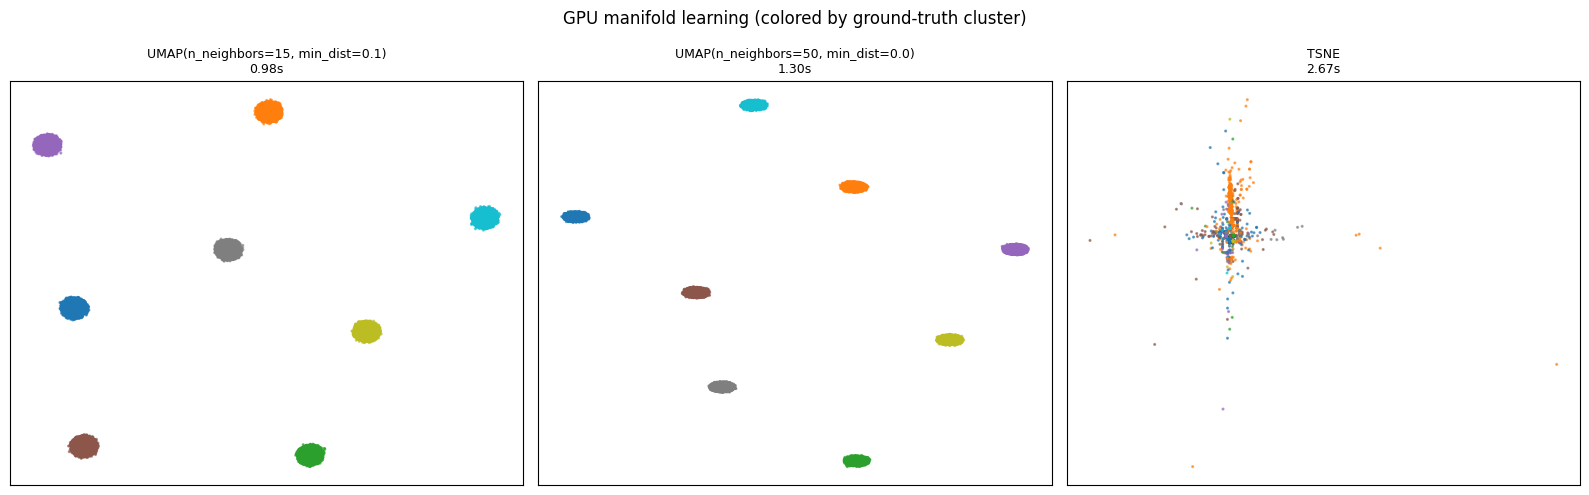

[section wall time: 9.8s]

  5. High-throughput forest inference (FIL / nvForest)
Training a 200-tree sklearn forest on CPU (the model to be served)...
    sklearn.predict_proba (CPU)                     0.642s
Loaded into FIL with kwargs={'is_classifier': True, 'output_type': 'numpy'}
Ran fil.optimize() to auto-tune layout/chunk size for this batch.
    FIL predict_proba (GPU)                         0.002s
    -> Forest inference (200 trees): 260.5x speedup

    max |prob difference| vs sklearn: 1.32e-07 (FIL defaults to float32, so ~1e-6 is normal)
[section wall time: 25.5s]

  6. GPU SHAP with cuml.explainer, validated analytically
    PermutationExplainer (GPU)                      0.992s
    max |SHAP - analytical linear SHAP| = 0.0000
    (permutation SHAP is sampling-based, so a small residual is expected; the pattern must match)
    additivity residual (mean |sum(phi)+base - f(x)|) = 0.0000


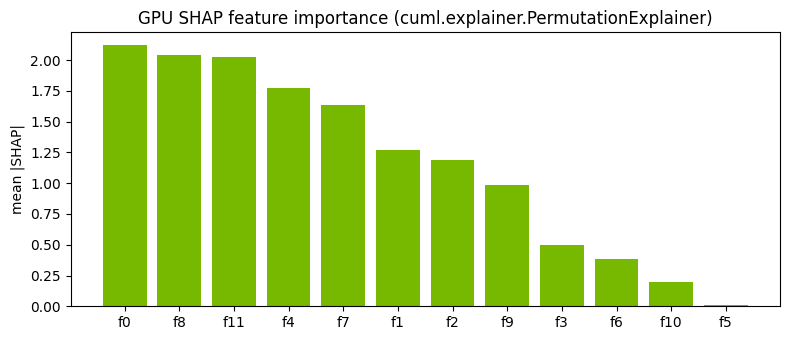

[section wall time: 2.0s]

  7. Hyperparameter search over cuML estimators
    RandomizedSearchCV over cuML RF (8 x 3 fits)   14.562s
    best CV accuracy: 0.9279
    best params     : {"n_estimators": 100, "n_bins": 256, "max_features": 0.5, "max_depth": 16}
[section wall time: 14.6s]

  8. Serialization and GPU -> CPU portability
    pickled model: 1.32 MB at /content/cuml_rf.pkl
    predictions identical after round trip: True
    cuML uses cloudpickle internally, so models trained under cuml.accel can be loaded and used by plain scikit-learn on a CPU-only machine.
    SECURITY: never unpickle a model file from an untrusted source.
[section wall time: 0.2s]

  9. Summary
task                                        CPU (s)   GPU (s)   speedup
-----------------------------------------------------------------------
cuml.accel (sklearn script, unmodified)       3.069     1.929      1.6x
Forest inference (200 trees)                  0.642     0.002    260.5x


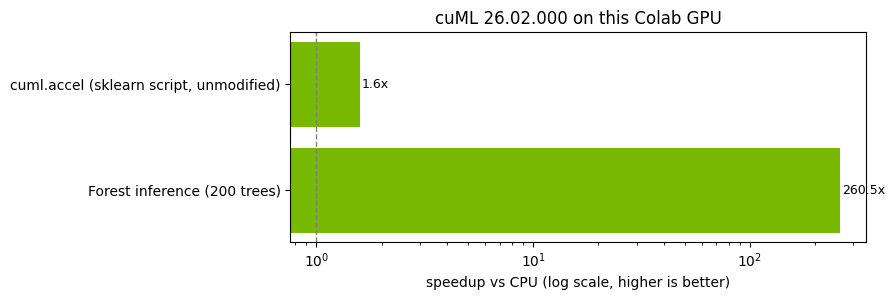


Takeaways
  1. cuml.accel needed ZERO source changes; the profile table above shows which calls ran on GPU and why Ridge(positive=True) fell back to CPU.
  2. Keep output_type as CuPy/cuDF inside a pipeline; converting to NumPy on every step forces a device->host copy and eats the speedup.
  3. FIL/nvForest is the piece that matters in production: the same trained artifact, served with GPU-class throughput and no retraining.
  4. Because each fit is seconds instead of minutes, you can afford a real search space instead of one hand-tuned guess.

  Caveats worth internalising:
   * Speedups are size-dependent. Under ~10k rows, PCIe transfer and kernel
     launch overhead usually dominate and the CPU wins. Benchmark YOUR shapes.
   * Always deviceSynchronize() before stopping a timer, or you time nothing.
   * cuML matches scikit-learn's API, not its exact numerics: different solvers,
     float32 defaults, and non-deterministic reductions produce small deltas.
   * Multi-GPU / multi-no

In [2]:
def demo_persistence():
    import pickle
    art = globals().get("_RF_ARTIFACTS")
    if art is None:
        from cuml.ensemble import RandomForestClassifier as cuRF
        Xg, yg = gpu_make_classification(n_samples=int(20_000 * SCALE),
                                         n_features=16, n_classes=2,
                                         random_state=SEED)
        Xg = Xg.astype(cp.float32); yg = yg.astype(cp.int32)
        model = cuRF(n_estimators=50, max_depth=10, random_state=SEED).fit(Xg, yg)
    else:
        model, Xg, yg, _, _ = art

    before = to_numpy(model.predict(Xg[:1000]))
    path = "/content/cuml_rf.pkl" if os.path.isdir("/content") else "cuml_rf.pkl"
    with open(path, "wb") as f:
        pickle.dump(model, f)
    size_mb = os.path.getsize(path) / 1e6
    with open(path, "rb") as f:
        restored = pickle.load(f)
    after = to_numpy(restored.predict(Xg[:1000]))
    print(f"    pickled model: {size_mb:.2f} MB at {path}")
    print(f"    predictions identical after round trip: {np.array_equal(before, after)}")
    print("    cuML uses cloudpickle internally, so models trained under "
          "cuml.accel can be loaded and used by plain scikit-learn on a "
          "CPU-only machine.")
    print("    SECURITY: never unpickle a model file from an untrusted source.")


def demo_summary():
    rows = [(t, c, g) for (t, c, g) in RESULTS if c and g]
    if not rows:
        print("No comparable timings were collected.")
        return
    w = max(len(r[0]) for r in rows)
    print(f"{'task'.ljust(w)}   {'CPU (s)':>9} {'GPU (s)':>9} {'speedup':>9}")
    print("-" * (w + 32))
    for t, c, g in rows:
        print(f"{t.ljust(w)}   {c:9.3f} {g:9.3f} {c / g:8.1f}x")

    labels = [r[0] for r in rows][::-1]
    speeds = [r[1] / r[2] for r in rows][::-1]
    plt.figure(figsize=(9, 0.55 * len(labels) + 2))
    bars = plt.barh(labels, speeds, color="#76b900")
    for b, s in zip(bars, speeds):
        plt.text(b.get_width() * 1.02, b.get_y() + b.get_height() / 2,
                 f"{s:.1f}x", va="center", fontsize=9)
    plt.axvline(1.0, color="grey", ls="--", lw=1)
    plt.xscale("log")
    plt.xlabel("speedup vs CPU (log scale, higher is better)")
    plt.title(f"cuML {cuml.__version__} on this Colab GPU")
    plt.tight_layout(); plt.show()

    print("\nTakeaways")
    for i, n in enumerate(NOTES, 1):
        print(f"  {i}. {n}")
    print("""
  Caveats worth internalising:
   * Speedups are size-dependent. Under ~10k rows, PCIe transfer and kernel
     launch overhead usually dominate and the CPU wins. Benchmark YOUR shapes.
   * Always deviceSynchronize() before stopping a timer, or you time nothing.
   * cuML matches scikit-learn's API, not its exact numerics: different solvers,
     float32 defaults, and non-deterministic reductions produce small deltas.
   * Multi-GPU / multi-node: swap cuml.X for cuml.dask.X with a LocalCUDACluster.

  Where to go next:
   * cuml.accel compatibility matrix : https://docs.nvidia.com/cuml/stable/cuml-accel/compatibility/
   * Profiling accelerated code      : %%cuml.accel.profile and %%cuml.accel.line_profile
   * Multi-GPU guide                 : https://docs.nvidia.com/cuml/stable/dask_multigpu_guide/
   * Walkthrough notebooks           : https://github.com/NVIDIA/cuml/tree/main/notebooks
""")


_t_all = time.perf_counter()
section("1. cuml.accel — zero code change acceleration of stock scikit-learn",
        demo_accel)
section("2. Native cuML API: cuDF/CuPy interop, zero-copy, output types",
        demo_native_api)
section("3. CPU vs GPU benchmark harness", demo_benchmarks)
section("4. UMAP -> trustworthiness -> HDBSCAN pipeline", demo_manifold)
section("5. High-throughput forest inference (FIL / nvForest)", demo_fil)
section("6. GPU SHAP with cuml.explainer, validated analytically", demo_explainer)
section("7. Hyperparameter search over cuML estimators", demo_hpo)
section("8. Serialization and GPU -> CPU portability", demo_persistence)
section("9. Summary", demo_summary)
print(f"\nTotal tutorial wall time: {time.perf_counter() - _t_all:.1f}s")